# Business Case Data — Réduction des Réadmissions Hospitalières < 30 jours

> **Domaine :** Santé hospitalière &nbsp;|&nbsp; **Approche :** Machine Learning Prédictif  

---

## Sommaire
1. [Définition du Problème & Domaine Métier](#1-définition-du-problème)
2. [Question Décisionnelle Centrale](#2-question-décisionnelle)
3. [KPIs Primaires & Secondaires](#3-kpis)
4. [KPI Tree Hiérarchique](#4-kpi-tree)
5. [Business Case & Modèle ROI](#5-business-case)
6. [Scénario Conservateur vs Ambitieux](#6-scénarios)
7. [Conclusion & Recommandations](#7-conclusion)

---
## Imports & Configuration

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import matplotlib.patheffects as pe
import warnings
warnings.filterwarnings('ignore')

# Style global
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

BLUE   = '#1E6091'
LBLUE  = '#2E86AB'
GREEN  = '#27AE60'
ORANGE = '#E67E22'
RED    = '#E74C3C'
GREY   = '#7F8C8D'
LGREY  = '#ECF0F1'

print("✅ Environnement prêt.")

✅ Environnement prêt.


---
<a id='1-définition-du-problème'></a>
## 1. Définition du Problème & Domaine Métier

### Domaine métier
Le secteur ciblé est la **santé hospitalière**. Les établissements MCO (Médecine, Chirurgie, Obstétrique) font face à une pression croissante pour réduire les **réadmissions non planifiées dans les 30 jours** suivant la sortie du patient.

### Contexte & enjeux
| Dimension | Détail |
|-----------|--------|
| **Population cible** | Patients adultes sortant d'hospitalisation MCO |
| **Fenêtre temporelle** | 30 jours calendaires post-sortie |
| **Sources de données** | EHR (dossier patient), PMSI (facturation), scores de fragilité |
| **Interventions possibles** | Appel J+7, téléconsultation, coordination infirmière à domicile |
| **Parties prenantes** | Direction médicale, DSI, équipes soignantes, direction financière |

> **Pourquoi la data ?** Le taux de réadmission est une métrique de qualité des soins surveillée par la HAS et un levier de performance financière (T2A). Un modèle ML prédictif permet de **cibler les interventions** là où elles ont le plus d'impact.

---
<a id='2-question-décisionnelle'></a>
## 2. Question Décisionnelle Centrale

> ### *« Quels patients sortants présentent un risque élevé de réadmission dans les 30 jours, et quelles interventions ciblées permettent de réduire ce risque de manière coût-efficace ? »*

Cette question se décompose en **3 sous-questions opérationnelles** :

1. **Prédiction** — Quel score de risque assigner à chaque patient à la sortie ?
2. **Segmentation** — Quel seuil de score déclenche une intervention active ?
3. **Optimisation** — Quel type d'intervention pour quel profil patient maximise le ROI ?

---
<a id='3-kpis'></a>
## 3. KPIs Primaires & Secondaires

In [13]:
# ── Tableau des KPIs ──────────────────────────────────────────────────────────

kpis = {
    "Niveau": [
        "🔴 Primaire", "🔴 Primaire", "🔴 Primaire", "🔴 Primaire",
        "🟡 Secondaire", "🟡 Secondaire", "🟡 Secondaire", "🟡 Secondaire",
        "🟢 Opérationnel ML", "🟢 Opérationnel ML", "🟢 Opérationnel ML", "🟢 Opérationnel ML",
    ],
    "KPI": [
        "Taux de réadmission < 30j (p0)",
        "Gain net annuel (€)",
        "ROI de la démarche data (%)",
        "Nombre de réadmissions évitées",
        "Taux d'adhésion au programme (%)",
        "Délai moyen sortie → 1er contact (j)",
        "Taux de contact effectif J+7 (%)",
        "Score de risque moyen (output ML)",
        "AUC-ROC du modèle prédictif",
        "Taux de faux positifs (%)",
        "Nb alertes générées / semaine",
        "Précision sur seuil de classification",
    ],
    "Cible": [
        "Réduire de ≥ 10 %",
        "> 0 € dès l'année 2",
        "> 50 % (scénario ambitieux)",
        "Maximiser",
        "> 80 %",
        "< 3 jours",
        "> 75 %",
        "Calibration continue",
        "> 0.75",
        "< 20 %",
        "Soutenable par l'équipe",
        "> 70 %",
    ],
    "Source": [
        "EHR / PMSI",
        "Contrôle de gestion",
        "Contrôle de gestion",
        "Calcul modèle",
        "CRM soignant",
        "CRM soignant",
        "CRM soignant",
        "Modèle ML",
        "Validation ML",
        "Validation ML",
        "Dashboard ops",
        "Validation ML",
    ]
}

df_kpis = pd.DataFrame(kpis)
df_kpis.index = range(1, len(df_kpis) + 1)
df_kpis.style.set_properties(**{'text-align': 'left'}) \
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#1E6091'), ('color', 'white'),
                                      ('font-weight', 'bold'), ('text-align', 'left')]},
        {'selector': 'tr:hover', 'props': [('background-color', '#EAF2FB')]},
    ]) \
    .apply(lambda col: [
        'background-color: #FDEDEC' if '🔴' in v
        else 'background-color: #FEF9E7' if '🟡' in v
        else 'background-color: #EAFAF1' if '🟢' in v
        else '' for v in col
    ], subset=['Niveau'])

,Niveau,KPI,Cible,Source
1,🔴 Primaire,Taux de réadmission < 30j (p0),Réduire de ≥ 10 %,EHR / PMSI
2,🔴 Primaire,Gain net annuel (€),> 0 € dès l'année 2,Contrôle de gestion
3,🔴 Primaire,ROI de la démarche data (%),> 50 % (scénario ambitieux),Contrôle de gestion
4,🔴 Primaire,Nombre de réadmissions évitées,Maximiser,Calcul modèle
5,🟡 Secondaire,Taux d'adhésion au programme (%),> 80 %,CRM soignant
6,🟡 Secondaire,Délai moyen sortie → 1er contact (j),< 3 jours,CRM soignant
7,🟡 Secondaire,Taux de contact effectif J+7 (%),> 75 %,CRM soignant
8,🟡 Secondaire,Score de risque moyen (output ML),Calibration continue,Modèle ML
9,🟢 Opérationnel ML,AUC-ROC du modèle prédictif,> 0.75,Validation ML
10,🟢 Opérationnel ML,Taux de faux positifs (%),< 20 %,Validation ML


---
<a id='4-kpi-tree'></a>
## 4. KPI Tree Hiérarchique

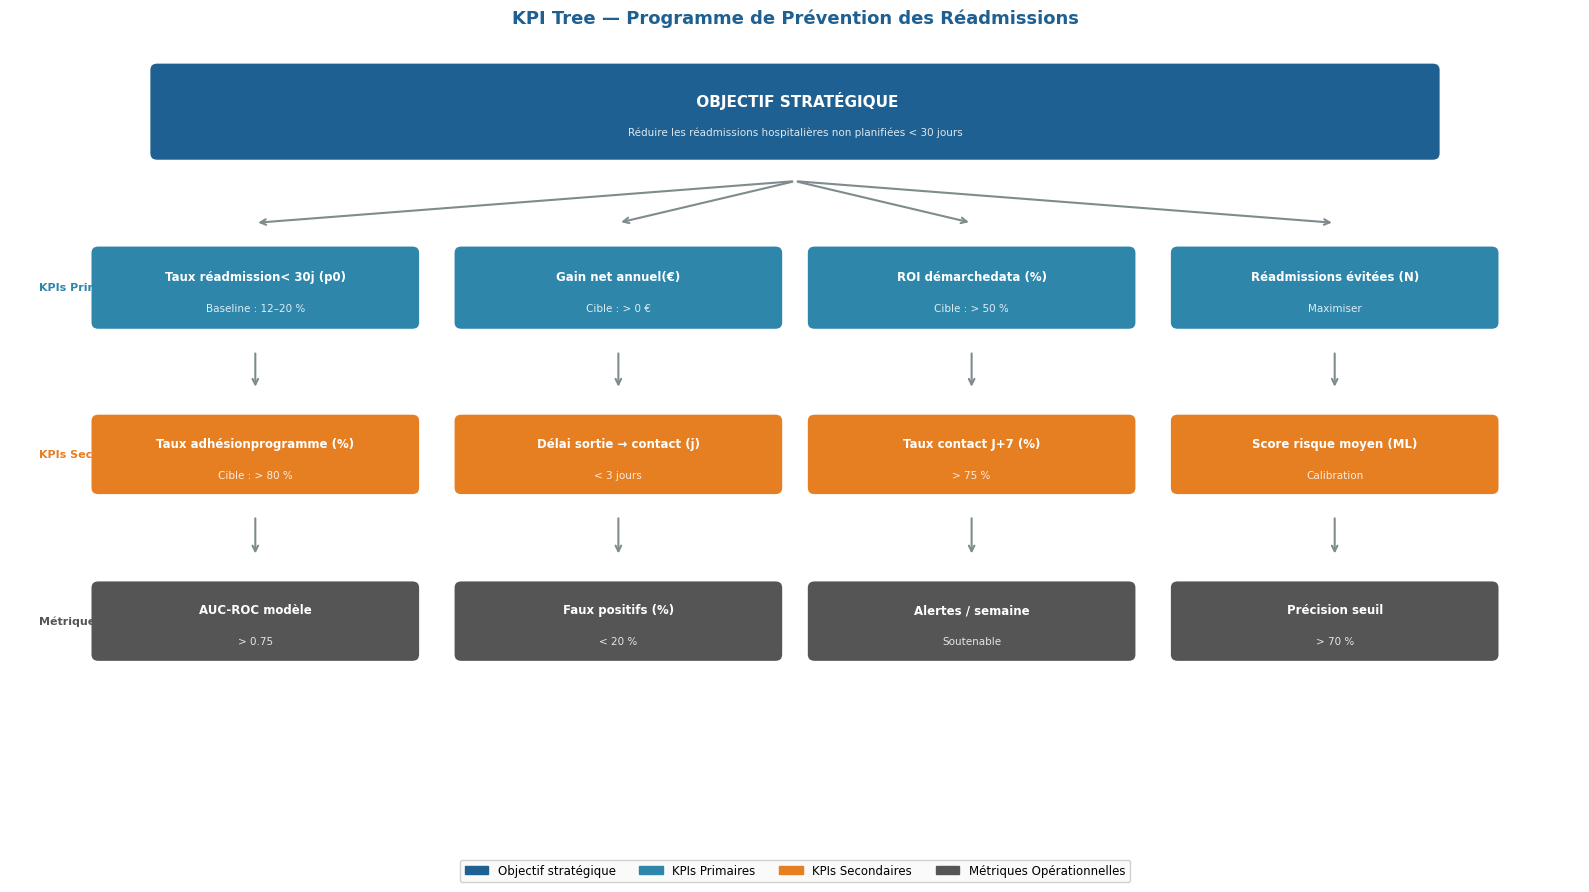

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

def draw_box(ax, x, y, w, h, label, sublabel='', color=BLUE, fontsize=9, text_color='white'):
    box = FancyBboxPatch((x - w/2, y - h/2), w, h,
                          boxstyle="round,pad=0.08", linewidth=1.5,
                          edgecolor='white', facecolor=color, zorder=3)
    ax.add_patch(box)
    ax.text(x, y + (0.12 if sublabel else 0), label, ha='center', va='center',
            fontsize=fontsize, fontweight='bold', color=text_color, zorder=4, wrap=True,
            multialignment='center')
    if sublabel:
        ax.text(x, y - 0.22, sublabel, ha='center', va='center',
                fontsize=7.5, color=text_color, alpha=0.85, zorder=4)

def arrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(x2, y2 + 0.3), xytext=(x1, y1 - 0.3),
                arrowprops=dict(arrowstyle='->', color=GREY, lw=1.5))

# ── Niveau 0 : Objectif stratégique ──
draw_box(ax, 8, 8.2, 13, 0.9,
         " OBJECTIF STRATÉGIQUE",
         "Réduire les réadmissions hospitalières non planifiées < 30 jours",
         color=BLUE, fontsize=11)

# ── Niveau 1 : KPIs Primaires ──
primaires = [
    ("Taux réadmission< 30j (p0)", "Baseline : 12–20 %"),
    ("Gain net annuel(€)", "Cible : > 0 €"),
    ("ROI démarchedata (%)", "Cible : > 50 %"),
    ("Réadmissions évitées (N)", "Maximiser"),
]
xs1 = [2.5, 6.2, 9.8, 13.5]
for x, (lab, sub) in zip(xs1, primaires):
    arrow(ax, 8, 7.75, x, 6.7)
    draw_box(ax, x, 6.3, 3.2, 0.75, lab, sub, color=LBLUE, fontsize=8.5)

ax.text(0.3, 6.3, "KPIs Primaires", ha='left', va='center',
        fontsize=8, color=LBLUE, fontweight='bold')

# ── Niveau 2 : KPIs Secondaires ──
secondaires = [
    ("Taux adhésionprogramme (%)", "Cible : > 80 %"),
    ("Délai sortie → contact (j)", "< 3 jours"),
    ("Taux contact J+7 (%)", "> 75 %"),
    ("Score risque moyen (ML)", "Calibration"),
]
xs2 = [2.5, 6.2, 9.8, 13.5]
for x, (lab, sub) in zip(xs2, secondaires):
    arrow(ax, xs1[xs2.index(x)], 5.92, x, 4.9)
    draw_box(ax, x, 4.5, 3.2, 0.72, lab, sub, color=ORANGE, fontsize=8.5)

ax.text(0.3, 4.5, "KPIs Secondaires", ha='left', va='center',
        fontsize=8, color=ORANGE, fontweight='bold')

# ── Niveau 3 : Métriques opérationnelles ──
ops = [
    ("AUC-ROC modèle", "> 0.75"),
    ("Faux positifs (%)", "< 20 %"),
    ("Alertes / semaine", "Soutenable"),
    ("Précision seuil", "> 70 %"),
]
xs3 = [2.5, 6.2, 9.8, 13.5]
for x, (lab, sub) in zip(xs3, ops):
    arrow(ax, xs2[xs3.index(x)], 4.14, x, 3.1)
    draw_box(ax, x, 2.7, 3.2, 0.72, lab, sub, color='#555555', fontsize=8.5)

ax.text(0.3, 2.7, "Métriques Opérationnelles (ML)", ha='left', va='center',
        fontsize=8, color='#555555', fontweight='bold')

# ── Légende ──
legend_items = [
    mpatches.Patch(color=BLUE, label='Objectif stratégique'),
    mpatches.Patch(color=LBLUE, label='KPIs Primaires'),
    mpatches.Patch(color=ORANGE, label='KPIs Secondaires'),
    mpatches.Patch(color='#555555', label='Métriques Opérationnelles'),
]
ax.legend(handles=legend_items, loc='lower center', ncol=4,
          fontsize=8.5, framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

plt.title("KPI Tree — Programme de Prévention des Réadmissions",
          fontsize=13, fontweight='bold', color=BLUE, pad=10)
plt.tight_layout()
plt.show()

---
<a id='5-business-case'></a>
## 5. Business Case & Modèle ROI

### Formules du modèle

$$\text{Réadmissions évitées} = N \times p_0 \times r$$

$$\text{Économies} = \text{Évitées} \times C_{\text{readm}}$$

$$\text{Coût programme} = N \times C_{\text{prog}}$$

$$\boxed{\text{Gain net} = \text{Économies} - \text{Coût programme}}$$

$$\text{ROI} = \frac{\text{Gain net}}{\text{Coût programme}} \times 100$$

In [15]:
# ── Paramètres & calcul ──────────────────────────────────────────────────────

scenarios = {
    "Conservateur": {
        "C_readm": 3000,   # coût moyen d'une réadmission (€)
        "C_prog":    75,   # coût intervention / patient (€)
        "N":        500,   # patients ciblés
        "p0":      0.15,   # taux baseline réadmission
        "r":       0.08,   # réduction relative attendue
        "color":   "#2E86AB",
    },
    "Ambitieux": {
        "C_readm": 3000,
        "C_prog":    50,
        "N":       1000,
        "p0":      0.18,
        "r":       0.15,
        "color":   "#27AE60",
    },
}

results = {}
for name, s in scenarios.items():
    evitees   = s["N"] * s["p0"] * s["r"]
    economies = evitees * s["C_readm"]
    cout      = s["N"]  * s["C_prog"]
    gain_net  = economies - cout
    roi       = (gain_net / cout) * 100

    results[name] = {
        **s,
        "evitees"   : round(evitees, 1),
        "economies" : round(economies),
        "cout"      : round(cout),
        "gain_net"  : round(gain_net),
        "roi"       : round(roi, 1),
    }
    print(f"{'─'*55}")
    print(f"   Scénario : {name}")
    print(f"{'─'*55}")
    print(f"  Patients ciblés (N)              : {s['N']}")
    print(f"  Taux baseline (p0)               : {s['p0']*100:.0f} %")
    print(f"  Réduction relative (r)           : {s['r']*100:.0f} %")
    print(f"  Coût/patient (C_prog)            : {s['C_prog']} €")
    print(f"  ──────────────────────────────────────────────")
    print(f"  Réadmissions évitées             : {evitees:.1f}")
    print(f"  Économies générées               : {economies:>10,.0f} €")
    print(f"  Coût programme                   : {cout:>10,.0f} €")
    print(f"  Gain net                         : {gain_net:>+10,.0f} €  {'✅' if gain_net > 0 else '⚠️'}")
    print(f"  ROI                              : {roi:>+9.1f} %  {'✅' if roi > 0 else '⚠️'}")
    print()

───────────────────────────────────────────────────────
   Scénario : Conservateur
───────────────────────────────────────────────────────
  Patients ciblés (N)              : 500
  Taux baseline (p0)               : 15 %
  Réduction relative (r)           : 8 %
  Coût/patient (C_prog)            : 75 €
  ──────────────────────────────────────────────
  Réadmissions évitées             : 6.0
  Économies générées               :     18,000 €
  Coût programme                   :     37,500 €
  Gain net                         :    -19,500 €  ⚠️
  ROI                              :     -52.0 %  ⚠️

───────────────────────────────────────────────────────
   Scénario : Ambitieux
───────────────────────────────────────────────────────
  Patients ciblés (N)              : 1000
  Taux baseline (p0)               : 18 %
  Réduction relative (r)           : 15 %
  Coût/patient (C_prog)            : 50 €
  ──────────────────────────────────────────────
  Réadmissions évitées             : 27.0
  

---
<a id='6-scénarios'></a>
## 6. Visualisation des Scénarios

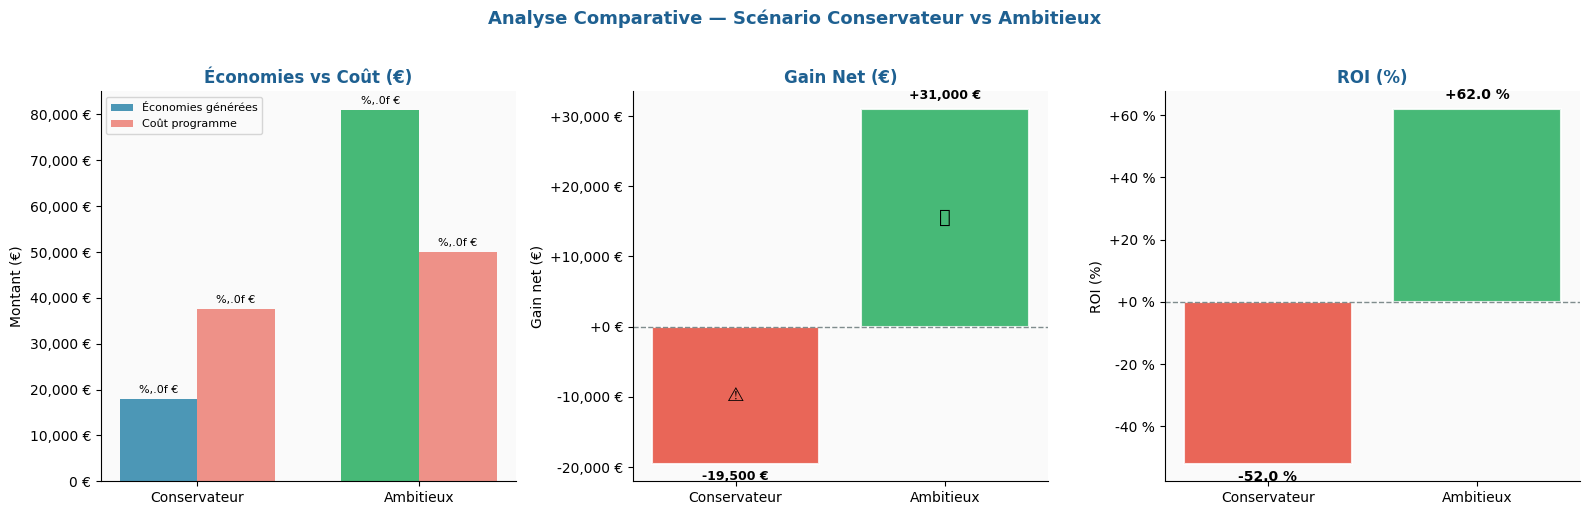

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Analyse Comparative — Scénario Conservateur vs Ambitieux",
             fontsize=13, fontweight='bold', color=BLUE, y=1.02)

names  = list(results.keys())
colors = [results[n]["color"] for n in names]

# ── Graphe 1 : Économies vs Coût ──────────────────────────────────────────
ax = axes[0]
x = np.arange(len(names))
w = 0.35
eco  = [results[n]["economies"] for n in names]
cout = [results[n]["cout"]      for n in names]
b1 = ax.bar(x - w/2, eco,  w, label="Économies générées", color=[LBLUE, GREEN], alpha=0.85)
b2 = ax.bar(x + w/2, cout, w, label="Coût programme",     color=[RED,   RED],   alpha=0.6)
ax.bar_label(b1, fmt='%,.0f €', padding=3, fontsize=8)
ax.bar_label(b2, fmt='%,.0f €', padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
ax.set_title("Économies vs Coût (€)", fontweight='bold', color=BLUE)
ax.set_ylabel("Montant (€)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:,.0f} €"))

# ── Graphe 2 : Gain net ──────────────────────────────────────────────────
ax = axes[1]
gains  = [results[n]["gain_net"] for n in names]
bar_colors = [RED if g < 0 else GREEN for g in gains]
bars = ax.bar(names, gains, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt=lambda v: f"{v:+,.0f} €", padding=5, fontsize=9, fontweight='bold')
ax.axhline(0, color=GREY, linewidth=1, linestyle='--')
ax.set_title("Gain Net (€)", fontweight='bold', color=BLUE)
ax.set_ylabel("Gain net (€)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+,.0f} €"))
for bar, gain in zip(bars, gains):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
            '✅' if gain > 0 else '⚠️', ha='center', va='center', fontsize=14)

# ── Graphe 3 : ROI ───────────────────────────────────────────────────────
ax = axes[2]
rois = [results[n]["roi"] for n in names]
bar_colors_roi = [RED if r < 0 else GREEN for r in rois]
bars = ax.bar(names, rois, color=bar_colors_roi, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.bar_label(bars, fmt=lambda v: f"{v:+.1f} %", padding=5, fontsize=10, fontweight='bold')
ax.axhline(0, color=GREY, linewidth=1, linestyle='--')
ax.set_title("ROI (%)", fontweight='bold', color=BLUE)
ax.set_ylabel("ROI (%)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0f} %"))

plt.tight_layout()
plt.show()

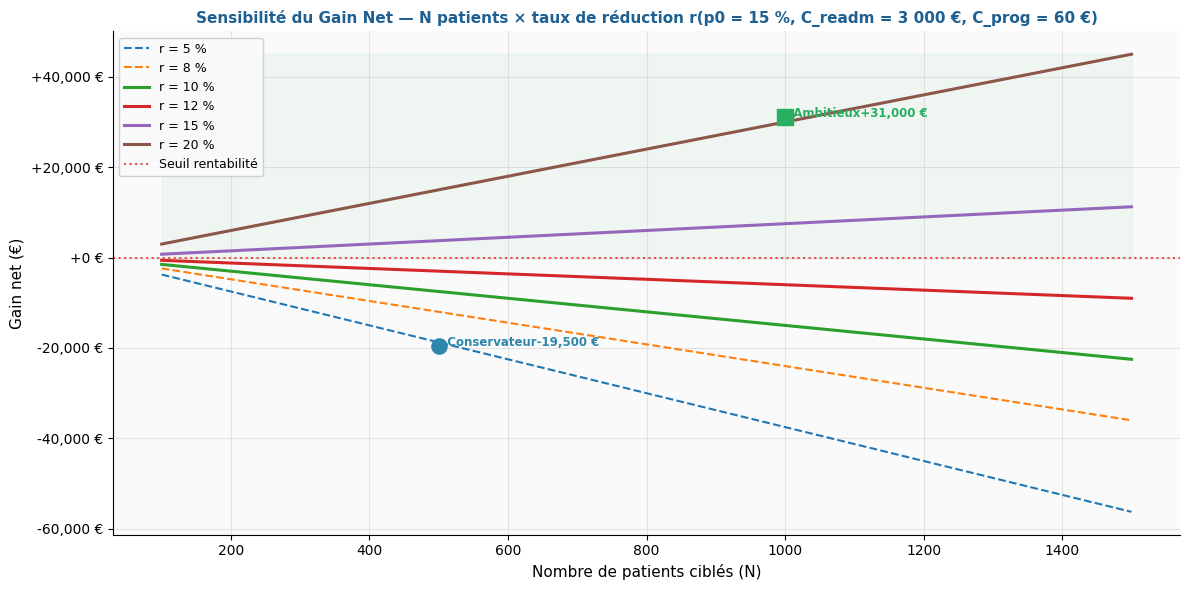

Le point d'équilibre (gain net = 0) est atteint pour r ≈ 8 % à N ≈ 750 patients.


In [ ]:
# ── Analyse de sensibilité : gain net en fonction de N et r ──────────────────

N_range = np.arange(100, 1501, 50)
r_values = [0.05, 0.08, 0.10, 0.12, 0.15, 0.20]

fig, ax = plt.subplots(figsize=(12, 6))

for r_val in r_values:
    gains = []
    for n in N_range:
        evitees   = n * 0.15 * r_val
        economies = evitees * 3000
        cout      = n * 60          # coût moyen interpolé
        gains.append(economies - cout)
    label = f"r = {r_val*100:.0f} %"
    style = '--' if r_val < 0.10 else '-'
    lw    = 1.5 if r_val < 0.10 else 2.2
    ax.plot(N_range, gains, label=label, linestyle=style, linewidth=lw)

ax.axhline(0, color=RED, linewidth=1.5, linestyle=':', label='Seuil rentabilité')
ax.fill_between(N_range, 0, max([
    (n * 0.15 * 0.20 * 3000) - n * 60 for n in N_range]), alpha=0.05, color=GREEN)

# Annotations scénarios
for name, marker, color in [("Conservateur", "o", LBLUE), ("Ambitieux", "s", GREEN)]:
    r = results[name]
    gain = r["gain_net"]
    n    = r["N"]
    ax.scatter(n, gain, s=120, color=color, zorder=5, marker=marker)
    ax.annotate(f"  {name}{gain:+,.0f} €", xy=(n, gain),
                fontsize=8.5, color=color, fontweight='bold')

ax.set_xlabel("Nombre de patients ciblés (N)", fontsize=11)
ax.set_ylabel("Gain net (€)", fontsize=11)
ax.set_title("Sensibilité du Gain Net — N patients × taux de réduction r(p0 = 15 %, C_readm = 3 000 €, C_prog = 60 €)",
             fontsize=11, fontweight='bold', color=BLUE)
ax.legend(loc='upper left', fontsize=9, framealpha=0.9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+,.0f} €"))
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("Le point d'équilibre (gain net = 0) est atteint pour r ≈ 8 % à N ≈ 750 patients.")

---
<a id='7-conclusion'></a>
## 7. Conclusion & Recommandations

### Synthèse des scénarios

| | **Scénario Conservateur** | **Scénario Ambitieux** |
|---|---|---|
| **Patients ciblés (N)** | 500 | 1 000 |
| **Réduction attendue (r)** | 8 % | 15 % |
| **Coût/patient** | 75 € | 50 € |
| **Réadmissions évitées** | ~6 | ~27 |
| **Économies** | 18 000 € | 81 000 € |
| **Coût programme** | 37 500 € | 50 000 € |
| **Gain net** | ⚠️ **−19 500 €** | ✅ **+31 000 €** |
| **ROI** | **−52 %** | **+62 %** |